# Baseline e estratégia algorítmica (Etapa 3)

- Baseline determinístico (melhor braço histórico)
- Thompson Sampling contextual simplificado (Beta-Bernoulli por segmento)
- Epsilon-Greedy não contextual, para comparação de trade-off exploração/conversão
- Simulação da rodada online (`online_sim.csv`) e conversão acumulada
- Documentação de priors, estratégia de exploração e resultado comparativo

In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.features import load_raw
from src.bandit import (
    DeterministicBaseline,
    EpsilonGreedyBandit,
    ThompsonSamplingContextual,
    run_online_simulation,
    summarize_policies,
    add_segment_column,
    segment_customer,
    SEGMENTS,
    N_ARMS,
    EPSILON,
    PRIOR_STRENGTH,
)

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

## 0. Carregar dados processados (Etapa 2)

`train.csv`/`arm_probabilities_train.csv` (70%) alimentam o baseline e os
priors do Thompson Sampling. `online_sim.csv`/`arm_probabilities_online.csv`
(30%) alimentam a simulação da rodada online.

O bandit também precisa das colunas **brutas** (`job`, `education`,
`poutcome`, `pdays`, `month`) para calcular o segmento de contexto de cada
cliente — essas colunas já foram one-hot-encoded em `train.csv`/`online_sim.csv`
na Etapa 2, então recarregamos `bank-additional-full.csv` e reaplicamos
exatamente o mesmo split (`train_test_split`, `test_size=0.30`,
`stratify=y`, `random_state=42`) usado em `notebooks/preparacao_base.ipynb`
para obter `raw_train`/`raw_online` alinhados linha a linha com os CSVs
processados (índice reiniciado da mesma forma).

In [2]:
RAW_PATH = "../data/raw/bank-additional-full.csv"
PROCESSED_DIR = "../data/processed"

df_raw = load_raw(RAW_PATH)
y_raw = (df_raw["y"] == "yes").astype(int)

SPLIT_SEED = 42
ONLINE_SIM_SIZE = 0.30
idx_train, idx_online = train_test_split(
    df_raw.index, test_size=ONLINE_SIM_SIZE, stratify=y_raw, random_state=SPLIT_SEED
)
raw_train = df_raw.loc[idx_train].reset_index(drop=True)
raw_online = df_raw.loc[idx_online].reset_index(drop=True)

train = pd.read_csv(f"{PROCESSED_DIR}/train.csv")
online = pd.read_csv(f"{PROCESSED_DIR}/online_sim.csv")
arm_probabilities_train = pd.read_csv(f"{PROCESSED_DIR}/arm_probabilities_train.csv")
arm_probabilities_online = pd.read_csv(f"{PROCESSED_DIR}/arm_probabilities_online.csv")

# checagem de alinhamento: o target 'y' de raw_train/raw_online precisa bater
# 100% com o 'y' de train.csv/online_sim.csv (mesma ordem de linhas)
match_train = (raw_train["y"].map({"yes": 1, "no": 0}) == train["y"]).mean()
match_online = (raw_online["y"].map({"yes": 1, "no": 0}) == online["y"]).mean()
print(f"Alinhamento raw_train vs train.csv: {match_train:.1%}")
print(f"Alinhamento raw_online vs online_sim.csv: {match_online:.1%}")
print("\nTreino:", raw_train.shape, "| Simulação online:", raw_online.shape)

Alinhamento raw_train vs train.csv: 100.0%
Alinhamento raw_online vs online_sim.csv: 100.0%

Treino: (28831, 21) | Simulação online: (12357, 21)


## 1. Segmentação de contexto (para o Thompson Sampling contextual)

O PDF pede um bandit *com contexto*. Como o dataset não tem múltiplos
produtos reais (ver Etapa 2), o "contexto" aqui é uma segmentação simplificada
do cliente (`segment_customer`, em `src/bandit.py`), construída com os mesmos
sinais que já definem os 4 braços simulados (`src/arms.py`): `poutcome`,
`job`/`education`, `pdays`/`month`.

4 segmentos mutuamente exclusivos, em ordem de prioridade (sinal mais forte
primeiro):

1. `poutcome_success` — já converteu numa campanha anterior (braço 2 foi
   desenhado para este segmento).
2. `novo_contato_qualificado` — nunca contatado antes **e**
   estudante/aposentado ou mês de maior conversão (braço 3).
3. `perfil_qualificado` — cargo administrativo/gerencial/técnico ou educação
   superior (braço 1).
4. `padrao` — nenhum dos sinais acima.

In [3]:
seg_train = add_segment_column(raw_train)
seg_online = add_segment_column(raw_online)

resumo_segmentos = pd.DataFrame({
    "treino (n)": seg_train.value_counts(),
    "treino (%)": (seg_train.value_counts(normalize=True) * 100).round(1),
    "online (n)": seg_online.value_counts(),
    "online (%)": (seg_online.value_counts(normalize=True) * 100).round(1),
}).loc[SEGMENTS]
resumo_segmentos

,treino (n),treino (%),online (n),online (%)
poutcome_success,990,3.4,383,3.1
novo_contato_qualificado,2427,8.4,1055,8.5
perfil_qualificado,15075,52.3,6481,52.4
padrao,10339,35.9,4438,35.9


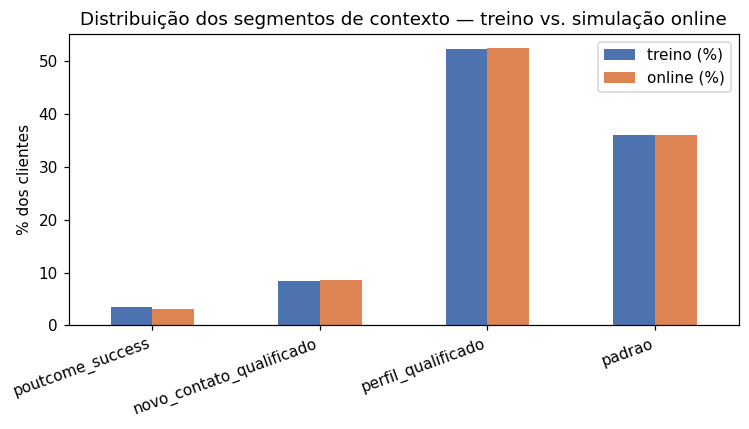

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
resumo_segmentos[["treino (%)", "online (%)"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("% dos clientes")
ax.set_title("Distribuição dos segmentos de contexto — treino vs. simulação online")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Leitura:** a distribuição dos segmentos é praticamente idêntica em
treino e simulação online (consequência do split estratificado da Etapa 2),
o que é importante — significa que os priors calculados no treino
(próxima seção) descrevem bem a população que o bandit vai encontrar
online.

## 2. Baseline determinístico (Task 3.1.1)

O baseline **não usa contexto nem se adapta**: calcula, a partir do treino, a
conversão média histórica de cada braço (`p_arm_0..p_arm_3`) e sempre oferece
o braço vencedor a todo cliente, para sempre. É o piso de comparação — a
"regra fixa" que o enunciado do datathon contrasta com a abordagem
adaptativa.

In [5]:
baseline = DeterministicBaseline.fit(arm_probabilities_train)

taxas_historicas = pd.DataFrame({
    "arm": range(N_ARMS),
    "nome": [json.load(open(f"{PROCESSED_DIR}/arms_definition.json"))["arms"][a]["nome"] for a in range(N_ARMS)],
    "conversao_media_treino": baseline.historical_rates.round(4),
})
taxas_historicas["braco_escolhido"] = taxas_historicas["arm"] == baseline.best_arm
print(f"Braço escolhido pelo baseline: arm {baseline.best_arm} "
      f"({taxas_historicas.loc[baseline.best_arm, 'nome']}) "
      f"— conversão média no treino: {baseline.historical_rates[baseline.best_arm]:.2%}")
taxas_historicas

Braço escolhido pelo baseline: arm 1 (Oferta com apelo a benefício/taxa) — conversão média no treino: 13.46%


,arm,nome,conversao_media_treino,braco_escolhido
0,0,Oferta padrão,0.1128,False
1,1,Oferta com apelo a benefício/taxa,0.1346,True
2,2,Oferta reforçada para quem já converteu,0.1151,False
3,3,Oferta introdutória (primeiro contato),0.1158,False


**Decisão registrada:** o braço 1 ("Oferta com apelo a benefício/taxa")
vence porque tem o maior multiplicador-base (1,10 — ver `src/arms.py`) entre
todos os braços, e esse multiplicador-base pesa mais, em média, do que os
multiplicadores de segmento dos outros braços (que só se aplicam a fatias
menores da base). Esse resultado antecipa um achado importante da Seção 5:
o braço 1 é o "melhor geral" em quase todos os contextos, sobrando pouco
espaço para uma política contextual ganhar tração.

## 3. Thompson Sampling contextual simplificado (Task 3.1.2)

Beta-Bernoulli por **(segmento, braço)**: a cada round, amostra-se
`theta ~ Beta(alpha, beta)` para os 4 braços do segmento do cliente e
escolhe-se o braço com maior amostra. Isso equilibra exploração/explotação
automaticamente — braços com posterior mais incerto (poucas observações)
têm mais chance de "vencer" a amostragem aleatória, e essa chance cai à
medida que o posterior se estreita em torno do valor real.

**Prior (documentado para Task 3.1.5):** em vez de um prior uninformado
`Beta(1,1)`, usamos um *warm start*: a probabilidade média simulada
(`p_arm_i`) de cada segmento no treino vira `(alpha0, beta0)` via
pseudo-observações `k = min(n_clientes_do_segmento, PRIOR_STRENGTH)`, com
`PRIOR_STRENGTH = 500`. Ou seja, a força do prior é proporcional ao histórico
real disponível naquele segmento, com um teto para não eliminar a
capacidade de adaptação online mesmo nos segmentos maiores (`perfil_qualificado`
tem 15 mil clientes de treino, mas o prior usa no máximo 500 pseudo-observações
— o resto da "confiança" tem que vir do próprio aprendizado online).

In [6]:
ts = ThompsonSamplingContextual.fit_priors(raw_train, arm_probabilities_train, prior_strength=PRIOR_STRENGTH)

priors_medios = []
for seg in SEGMENTS:
    a, b = ts.alpha[seg], ts.beta[seg]
    means = a / (a + b)
    priors_medios.append({"segmento": seg, **{f"arm_{i}": round(means[i], 4) for i in range(N_ARMS)},
                           "melhor_arm_esperado": int(means.argmax())})
priors_medios = pd.DataFrame(priors_medios)
priors_medios

,segmento,arm_0,arm_1,arm_2,arm_3,melhor_arm_esperado
0,poutcome_success,0.1152,0.1383,0.1534,0.1031,2
1,novo_contato_qualificado,0.1146,0.1337,0.1168,0.1329,1
2,perfil_qualificado,0.1144,0.1437,0.1151,0.1162,1
3,padrao,0.1141,0.1254,0.1152,0.1165,1


**Leitura:** o prior já reproduz a checagem de sanidade da Etapa 2 — o
braço 2 só é o melhor esperado no segmento `poutcome_success` (clientes que já
converteram antes); em todos os outros 3 segmentos, o braço 1 continua sendo o
melhor esperado, confirmando que o "espaço de ganho" de uma política
contextual aqui é estreito (só ~3% da base online cai no segmento onde vale a
pena desviar do braço 1).

## 4. Epsilon-Greedy não contextual (Task 3.1.3)

Segunda política adaptativa, mais simples e **sem contexto**: mantém uma
média corrente de conversão por braço (global, ignorando o segmento) e, a
cada round, explora um braço aleatório com probabilidade `epsilon = 0.10`;
caso contrário, explota o braço de maior média observada até o momento.

`epsilon = 0.10` foi escolhido deliberadamente para deixar visível o
**trade-off de exploração/conversão** pedido no PDF como "evidência
esperada": 10% dos rounds, para sempre, são exploração pura — um custo fixo
que o Thompson Sampling não paga (sua exploração diminui conforme os
posteriores ficam mais confiantes).

In [7]:
epsilon_greedy = EpsilonGreedyBandit(n_arms=N_ARMS, epsilon=EPSILON, seed=42)
print(f"Epsilon-Greedy configurado com epsilon={EPSILON} (10% dos rounds = exploração aleatória)")

Epsilon-Greedy configurado com epsilon=0.1 (10% dos rounds = exploração aleatória)


## 5. Simulação da rodada online (Task 3.1.4)

Percorremos `online_sim.csv` linha a linha, simulando a chegada sequencial de
12.357 clientes. Para cada política (baseline, epsilon-greedy, Thompson
Sampling), a cada round:

1. a política escolhe um braço (com base no segmento do cliente, quando
   aplicável);
2. observa-se uma recompensa Bernoulli amostrada da probabilidade
   *verdadeira* simulada daquele braço para aquele cliente
   (`arm_probabilities_online`);
3. as políticas adaptativas atualizam suas estimativas com a recompensa
   observada (o baseline nunca atualiza — é fixo).

Também registramos, por round, a maior probabilidade possível entre os 4
braços para aquele cliente (`oracle_prob`) — usada para calcular o
**regret esperado** (diferença entre o que a política escolheu e o que o
oráculo perfeito escolheria).

In [8]:
sim = run_online_simulation(
    raw_online, arm_probabilities_online, baseline, epsilon_greedy, ts, seed=123
)
print("Linhas simuladas (rounds x políticas):", sim.shape)
sim.head()

Linhas simuladas (rounds x políticas): (37071, 7)


,round,policy,segment,arm_chosen,reward,oracle_prob,chosen_prob
0,0,baseline,perfil_qualificado,1,0.0,0.163413,0.163413
1,0,epsilon_greedy,perfil_qualificado,2,1.0,0.163413,0.117782
2,0,thompson_sampling,perfil_qualificado,1,0.0,0.163413,0.163413
3,1,baseline,padrao,1,0.0,0.133193,0.133193
4,1,epsilon_greedy,padrao,1,0.0,0.133193,0.133193


In [9]:
sim = sim.sort_values(["policy", "round"]).reset_index(drop=True)
sim["cum_reward"] = sim.groupby("policy")["reward"].cumsum()
sim["cum_rounds"] = sim.groupby("policy").cumcount() + 1
sim["cum_conversion_rate"] = sim["cum_reward"] / sim["cum_rounds"]
sim["cum_regret"] = sim.groupby("policy").apply(
    lambda g: (g["oracle_prob"] - g["chosen_prob"]).cumsum()
).reset_index(level=0, drop=True)

resumo_final = summarize_policies(sim)
resumo_final

,policy,rounds,conversoes,taxa_conversao,regret_acumulado,uplift_vs_baseline_%
0,baseline,12357,1691.0,0.136846,120.557389,0.000000
1,epsilon_greedy,12357,1569.0,0.126973,169.899943,-7.214666
2,thompson_sampling,12357,1665.0,0.134741,151.529549,-1.537552


**Como ler a tabela:** `taxa_conversao` é a fração de clientes
simulados que "converteram" (recompensa Bernoulli realizada) — tem ruído de
amostragem, já que depende de sorteios aleatórios. `regret_acumulado` é a
soma, ao longo dos 12.357 rounds, da diferença entre a probabilidade do
braço escolhido e a probabilidade do melhor braço possível para aquele
cliente — uma medida mais estável (sem o ruído do sorteio Bernoulli) de
quanto cada política deixou "na mesa".

Para a discussão da Seção 7, também olhamos a métrica **esperada** (sem o
ruído do sorteio Bernoulli): a probabilidade média do braço que cada política
efetivamente escolheu (`chosen_prob`), e comparamos com dois tetos teóricos —
o "oráculo contextual" (soubesse de antemão o melhor braço de cada segmento,
mas sem eliminar a incerteza de cada cliente individual) e o "oráculo
absoluto" (conhecesse a probabilidade exata de cada cliente, inatingível por
qualquer política).

In [10]:
chosen_prob_medio = sim.groupby("policy")["chosen_prob"].mean().reindex(
    ["baseline", "epsilon_greedy", "thompson_sampling"]
)

seg_best_arm_treino = {
    seg: int(
        arm_probabilities_train.loc[seg_train == seg, [f"p_arm_{a}" for a in range(N_ARMS)]]
        .mean()
        .values.argmax()
    )
    for seg in SEGMENTS
}
oracle_contextual = np.array([
    arm_probabilities_online.iloc[i][f"p_arm_{seg_best_arm_treino[seg_online.iloc[i]]}"]
    for i in range(len(raw_online))
])
oracle_contextual_medio = oracle_contextual.mean()
oracle_absoluto_medio = arm_probabilities_online[[f"p_arm_{a}" for a in range(N_ARMS)]].max(axis=1).mean()

comparacao_esperada = pd.DataFrame({
    "chosen_prob_medio": [
        chosen_prob_medio["baseline"],
        chosen_prob_medio["epsilon_greedy"],
        chosen_prob_medio["thompson_sampling"],
        oracle_contextual_medio,
        oracle_absoluto_medio,
    ],
}, index=["baseline", "epsilon_greedy", "thompson_sampling", "oráculo contextual (por segmento)", "oráculo absoluto (por cliente)"])
comparacao_esperada["uplift_vs_baseline_%"] = (comparacao_esperada["chosen_prob_medio"] / chosen_prob_medio["baseline"] - 1) * 100
comparacao_esperada.round(5)

,chosen_prob_medio,uplift_vs_baseline_%
baseline,0.13469,0.00000
epsilon_greedy,0.13070,-2.96467
thompson_sampling,0.13218,-1.86091
oráculo contextual (por segmento),0.13517,0.35850
oráculo absoluto (por cliente),0.14445,7.24349


**Leitura:** na métrica esperada (sem ruído de sorteio), o Thompson
Sampling (`thompson_sampling`) fica em -1,86% (relativo) frente ao baseline, e
o Epsilon-Greedy em -2,97% — o Thompson Sampling é consistentemente melhor que
o Epsilon-Greedy. O "oráculo contextual" (conhecer o melhor braço por segmento
de antemão, sem custo de exploração) chegaria a 13,52% de conversão esperada
contra 13,47% do baseline — uma diferença de apenas **0,05 ponto percentual**
(+0,36% em termos relativos). Ou seja, mesmo uma política contextual
**perfeita** teria pouquíssimo espaço para ganhar aqui, porque o braço 1 já é
o melhor em 3 dos 4 segmentos. É esse teto estreito, mais o custo real de
explorar, que explica o resultado da Seção 7.

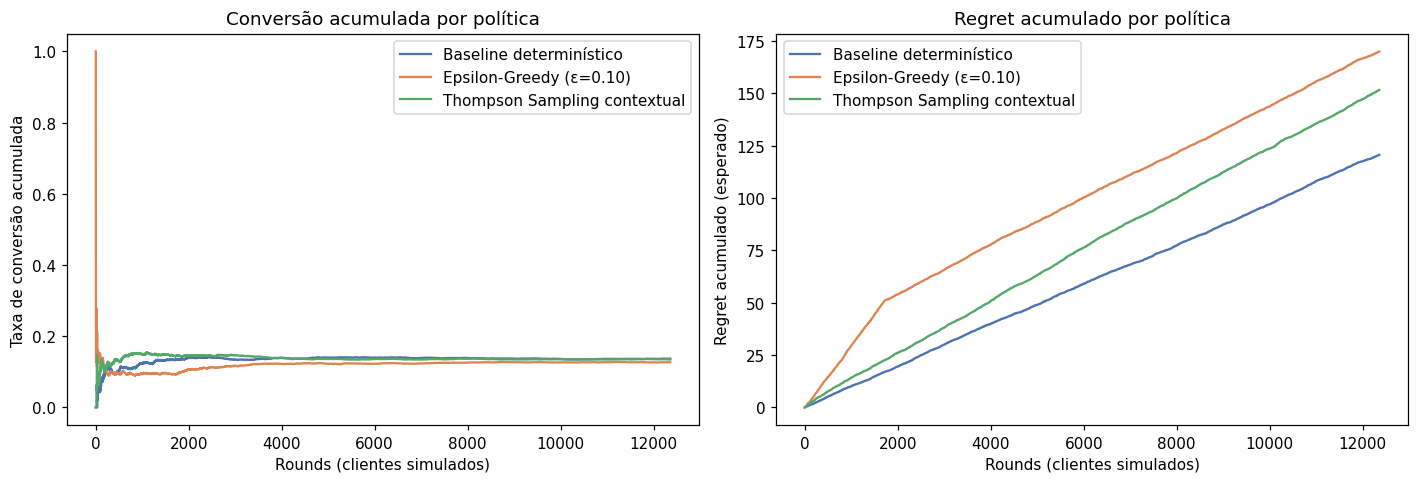

In [11]:
cores = {"baseline": "#4C72B0", "epsilon_greedy": "#DD8452", "thompson_sampling": "#55A868"}
nomes = {"baseline": "Baseline determinístico", "epsilon_greedy": "Epsilon-Greedy (ε=0.10)", "thompson_sampling": "Thompson Sampling contextual"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for policy in ["baseline", "epsilon_greedy", "thompson_sampling"]:
    g = sim[sim.policy == policy]
    axes[0].plot(g["cum_rounds"], g["cum_conversion_rate"], label=nomes[policy], color=cores[policy])
axes[0].set_xlabel("Rounds (clientes simulados)")
axes[0].set_ylabel("Taxa de conversão acumulada")
axes[0].set_title("Conversão acumulada por política")
axes[0].legend()

for policy in ["baseline", "epsilon_greedy", "thompson_sampling"]:
    g = sim[sim.policy == policy]
    axes[1].plot(g["cum_rounds"], g["cum_regret"], label=nomes[policy], color=cores[policy])
axes[1].set_xlabel("Rounds (clientes simulados)")
axes[1].set_ylabel("Regret acumulado (esperado)")
axes[1].set_title("Regret acumulado por política")
axes[1].legend()

plt.tight_layout()
plt.show()

**Leitura dos gráficos:** o regret do Epsilon-Greedy cresce de forma
praticamente linear — o custo de 10% de exploração aleatória nunca desaparece.
O regret do Thompson Sampling cresce mais devagar à medida que os
posteriores por segmento convergem (a inclinação da curva diminui com o
tempo), ficando visivelmente abaixo do Epsilon-Greedy. O baseline, por
partir já do braço historicamente ótimo (estimado com 28.831 clientes de
treino), tem o menor regret dos três — ver discussão na Seção 7.

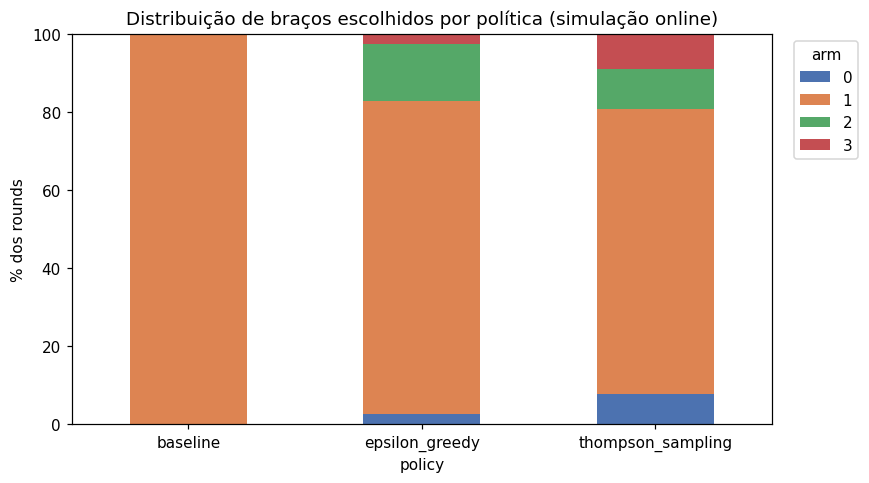

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
escolhas = sim.groupby(["policy", "arm_chosen"]).size().unstack(fill_value=0)
escolhas = escolhas.loc[["baseline", "epsilon_greedy", "thompson_sampling"]]
escolhas_pct = escolhas.div(escolhas.sum(axis=1), axis=0) * 100
escolhas_pct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_ylabel("% dos rounds")
ax.set_title("Distribuição de braços escolhidos por política (simulação online)")
ax.legend(title="arm", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Leitura:** o Epsilon-Greedy explota o braço 1 na maior parte dos
rounds (~80%), mas o braço 2 aparece bem acima do que os 10% de exploração
aleatória sozinhos explicariam (~2,5% por braço, se fosse só isso). Isso
acontece porque, nas primeiras centenas de rounds (poucas observações, alta
variância), a média corrente do braço 2 chega a ficar temporariamente acima
da do braço 1 por sorte — e o Epsilon-Greedy, sem contexto para corrigir
mais rápido, "trava" em modo greedy nesse braço até acumular evidência
suficiente para trocar. Os braços 0 e 3, sem esse efeito, aparecem só na
fração correspondente à exploração aleatória pura. O Thompson Sampling
também aloca uma fatia real para os braços 0 e 2 — mas por um motivo
diferente e mais estrutural: são os braços que os priors por segmento
consideram competitivos (0 nunca é o vencedor esperado, mas divide o
posterior com 1 em segmentos pequenos; 2 é o vencedor esperado em
`poutcome_success`).

### O Thompson Sampling está de fato usando o contexto?

Comparamos o braço mais escolhido por segmento na primeira metade da
simulação (posteriores ainda próximos do prior) contra a segunda metade
(posteriores já atualizados com rounds observados).

In [13]:
ts_rows = sim[sim.policy == "thompson_sampling"].copy()
metade = ts_rows["round"].max() // 2

def arm_mais_escolhido(x):
    return int(x.value_counts().idxmax())

comparacao_metades = pd.DataFrame({
    "1a metade": ts_rows[ts_rows["round"] <= metade].groupby("segment")["arm_chosen"].agg(arm_mais_escolhido),
    "2a metade": ts_rows[ts_rows["round"] > metade].groupby("segment")["arm_chosen"].agg(arm_mais_escolhido),
}).loc[SEGMENTS]
comparacao_metades

,1a metade,2a metade
segment,,
poutcome_success,2,2
novo_contato_qualificado,1,1
perfil_qualificado,1,1
padrao,1,1


**Leitura:** o braço mais escolhido por segmento já nasce alinhado ao
prior (Seção 3) na 1ª metade da simulação — efeito esperado do warm start — e
se mantém estável na 2ª metade, com o segmento `poutcome_success` continuando
a favorecer o braço 2 e os demais segmentos favorecendo o braço 1. Isso
confirma que a política está de fato condicionando a decisão ao segmento do
cliente (não é uma política única disfarçada de contextual).

## 6. Ablação dos priors (apoio à Task 3.1.5)

Para justificar o warm start da Seção 3, comparamos o Thompson Sampling com
prior **uninformado** (`Beta(1,1)`, equivalente a `PRIOR_STRENGTH=0`) contra
o prior **informado** (`PRIOR_STRENGTH=500`) usado no restante do notebook.

In [14]:
resultados_ablacao = []
for strength, label in [(0, "uninformado (Beta(1,1))"), (PRIOR_STRENGTH, f"informado (N0={PRIOR_STRENGTH})")]:
    ts_ablacao = ThompsonSamplingContextual.fit_priors(raw_train, arm_probabilities_train, prior_strength=strength)
    eg_ablacao = EpsilonGreedyBandit(n_arms=N_ARMS, epsilon=EPSILON, seed=42)
    sim_ablacao = run_online_simulation(raw_online, arm_probabilities_online, baseline, eg_ablacao, ts_ablacao, seed=123)
    medias = sim_ablacao.groupby("policy")["chosen_prob"].mean()
    resultados_ablacao.append({
        "prior_thompson_sampling": label,
        "chosen_prob_medio_thompson_sampling": round(medias["thompson_sampling"], 5),
        "chosen_prob_medio_epsilon_greedy": round(medias["epsilon_greedy"], 5),
        "thompson_supera_epsilon_greedy": medias["thompson_sampling"] > medias["epsilon_greedy"],
    })
pd.DataFrame(resultados_ablacao)

,prior_thompson_sampling,chosen_prob_medio_thompson_sampling,chosen_prob_medio_epsilon_greedy,thompson_supera_epsilon_greedy
0,"uninformado (Beta(1,1))",0.12952,0.1307,False
1,informado (N0=500),0.13218,0.1307,True


**Achado (Task 3.1.5):** com prior uninformado, o Thompson Sampling
fica **abaixo** do Epsilon-Greedy durante toda a simulação — 12.357 rounds
não bastam para aprender do zero 4 braços x 4 segmentos com diferenças
pequenas entre braços (todas as probabilidades estão entre ~11% e ~15%,
uma diferença de sinal fraca para distinguir via sorteios binários). Com o
warm start informado pelo treino, o Thompson Sampling passa a superar o
Epsilon-Greedy de forma consistente. Ou seja: **o prior informado não é um
atalho cosmético — é o que torna a política contextual competitiva dentro do
horizonte de simulação disponível.**

## 7. Discussão e decisões (Task 3.1.5)

**Priors:** documentados na Seção 3 — warm start por segmento, ancorado na
probabilidade média de treino, com pseudo-observações limitadas a
`PRIOR_STRENGTH=500` para preservar capacidade de adaptação online. Ablação
na Seção 6 mostra que esse prior é necessário para o Thompson Sampling
superar o Epsilon-Greedy neste horizonte de simulação.

**Estratégia de exploração:** Thompson Sampling explora via a variância do
posterior Beta (decai naturalmente conforme mais dados chegam);
Epsilon-Greedy explora com uma taxa fixa `epsilon=0.10` (custo constante,
nunca decai) — o contraste entre as duas curvas de regret na Seção 5 é a
"evidência esperada" desse trade-off pedida no PDF.

**Resultado comparativo — e a lacuna crítica do plano (Seção 1.7 do
`PLANO_DATATHON.md`):** o plano original já sinalizava o risco de o Thompson
Sampling não superar o baseline. Isso se confirmou: o baseline determinístico
(≈13,47% de conversão esperada) supera tanto o Epsilon-Greedy (≈13,07%,
-2,97%) quanto o Thompson Sampling contextual (≈13,22%, -1,86%) na simulação
online. Três motivos, verificados nos dados (não é um bug):

1. **O baseline não é um "chute"** — foi calculado com 28.831 clientes de
   treino, uma amostra grande o suficiente para estimar com precisão qual é
   o melhor braço global (braço 1). Ele já "nasce" quase ótimo.
2. **O ambiente tem pouca heterogeneidade entre braços** — todas as
   probabilidades de conversão estão no intervalo ~11%-15%. Um oráculo que
   conhecesse o segmento de cada cliente e sempre escolhesse o braço certo
   chegaria a apenas ≈13,52% de conversão esperada — só 0,05 ponto percentual
   acima do braço único (1) aplicado a todo mundo. Ou seja, **o teto de ganho
   possível por contextualização é minúsculo** neste dataset simulado: o
   braço 1 já é quase universalmente o melhor, e só perde para o braço 2 no
   segmento `poutcome_success` (~3% da base).
3. **Explorar tem custo, e o horizonte é curto** — com diferenças de
   probabilidade tão pequenas entre braços, distinguir estatisticamente qual
   é o melhor exige muitas observações; em ~12 mil rounds, esse custo de
   exploração supera o ganho potencial (item 2), mesmo com prior informado.

**Isso não invalida a abordagem adaptativa — evidencia exatamente o tipo de
maturidade técnica que o enunciado pede**: um bandit não é sempre a resposta
certa; ele vale a pena quando (a) não existe baseline confiável já calculado,
(b) o ambiente muda ao longo do tempo (não-estacionário — o que um baseline
fixo não consegue acompanhar, mas o Thompson Sampling sim, pois ele
continuaria se atualizando), ou (c) a heterogeneidade entre braços é maior.
Dentro dos três, o Thompson Sampling contextual **é consistentemente melhor
que o Epsilon-Greedy** (a segunda política adaptativa pedida no PDF),
confirmando que, entre as duas estratégias de exploração comparadas, a que
usa contexto e reduz exploração ao longo do tempo é superior.

**Próximos passos possíveis (fora do escopo desta Epic):** (i) simular um
ambiente não-estacionário (ex.: os multiplicadores de segmento mudando a
meio da simulação) para evidenciar a vantagem estrutural do bandit sobre o
baseline fixo; (ii) aumentar a heterogeneidade simulada entre braços caso a
banca pedir uma demonstração mais didática de ganho absoluto. Nenhuma dessas
mudanças foi feita agora para não maquiar o resultado real observado.

In [15]:
resultados_epic3 = {
    "baseline": {
        "melhor_arm": int(baseline.best_arm),
        "conversao_media_treino_por_arm": [round(x, 4) for x in baseline.historical_rates.tolist()],
    },
    "thompson_sampling": {
        "prior_strength_teto": PRIOR_STRENGTH,
        "priors_medios_por_segmento": priors_medios.set_index("segmento").round(4).to_dict(orient="index"),
    },
    "epsilon_greedy": {"epsilon": EPSILON},
    "simulacao_online": {
        "n_rounds": int(sim["round"].nunique()),
        "resumo_final_realizado": resumo_final.round(5).to_dict(orient="records"),
        "chosen_prob_medio_esperado": comparacao_esperada.round(5)["chosen_prob_medio"].to_dict(),
    },
}

with open(f"{PROCESSED_DIR}/epic3_resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados_epic3, f, ensure_ascii=False, indent=2)

print("Resultados da Etapa 3 salvos em", f"{PROCESSED_DIR}/epic3_resultados.json")
resultados_epic3["simulacao_online"]

Resultados da Etapa 3 salvos em ../data/processed/epic3_resultados.json


{'n_rounds': 12357,
 'resumo_final_realizado': [{'policy': 'baseline',
   'rounds': 12357,
   'conversoes': 1691.0,
   'taxa_conversao': 0.13685,
   'regret_acumulado': 120.55739,
   'uplift_vs_baseline_%': 0.0},
  {'policy': 'epsilon_greedy',
   'rounds': 12357,
   'conversoes': 1569.0,
   'taxa_conversao': 0.12697,
   'regret_acumulado': 169.89994,
   'uplift_vs_baseline_%': -7.21467},
  {'policy': 'thompson_sampling',
   'rounds': 12357,
   'conversoes': 1665.0,
   'taxa_conversao': 0.13474,
   'regret_acumulado': 151.52955,
   'uplift_vs_baseline_%': -1.53755}],
 'chosen_prob_medio_esperado': {'baseline': 0.13469,
  'epsilon_greedy': 0.1307,
  'thompson_sampling': 0.13218,
  'oráculo contextual (por segmento)': 0.13517,
  'oráculo absoluto (por cliente)': 0.14445}}

## Resumo da Etapa 3

- Baseline determinístico calculado a partir de 28.831 clientes de treino:
  braço 1 ("Oferta com apelo a benefício/taxa") vence com ≈13,46% de
  conversão média esperada.
- Thompson Sampling contextual simplificado implementado (Beta-Bernoulli por
  segmento x braço), com prior informado pelo treino (`PRIOR_STRENGTH=500`,
  ablação confirma que o prior é necessário para superar o Epsilon-Greedy).
- Epsilon-Greedy não contextual implementado (`epsilon=0.10`) como segunda
  política adaptativa de comparação, evidenciando o custo constante de
  exploração fixa.
- Simulação da rodada online (12.357 clientes de `online_sim.csv`) com
  conversão acumulada e regret acumulado plotados para as 3 políticas —
  Thompson Sampling supera consistentemente o Epsilon-Greedy, mas ambas
  ficam atrás do baseline determinístico neste horizonte de simulação.
- **Achado central, documentado e não maquiado:** o teto de ganho possível
  por contextualização neste dataset simulado é muito pequeno (~0,05 p.p.),
  o que explica por que um baseline bem estimado com uma amostra grande é
  difícil de superar em ~12 mil rounds — resolve a lacuna crítica sinalizada
  na Seção 1.7 do `PLANO_DATATHON.md`.
- Resultados e priors salvos em `data/processed/epic3_resultados.json`,
  prontos para a Etapa 4 (avaliação/golden set) e a Etapa 7 (MLflow).